In [1]:
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import seaborn as sns

In [37]:
def plot_rbp_activity_heatmap(cell_line):
    
    print(cell_line)
    
    # read in data 
    
    data_path = f"/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/{cell_line}_all-data.feather"
    
    data = pl.read_ipc(data_path)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 6 sig. points 

            if (num_pos + num_neg) < 6:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    # Can test for an individual RBP
    # test = results_df[results_df["RBP"] == ""]
    # print(test)
    
    df = pd.DataFrame(results_df)

    # Pivot the dataframe to have positions as columns, RBPs as rows, and score as values
    heatmap_data = df.pivot(index='RBP', columns='position', values='norm_diff')

    # Plot
    plt.figure(figsize=(6,16))
    ax = sns.heatmap(
        heatmap_data, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm",
        center = 0,
        cbar_kws={'label': 'Normalized Difference Score'},
        linewidths=0.5,
        linecolor='gray'
    )

    cbar = plt.gcf().axes[-1]  # Get colorbar axis
    cbar.set_ylabel('Normalized Difference Score', fontsize=18, labelpad=20)

    # Axis labels with font size and labelpad
    plt.xlabel("Position", fontsize=18, labelpad=20)
    plt.ylabel("RBP", fontsize=18, labelpad=20)
    plt.title(f"{cell_line}: RBP Activity Score", fontsize=20, pad=20)
    return ax

## HepG2

HepG2


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


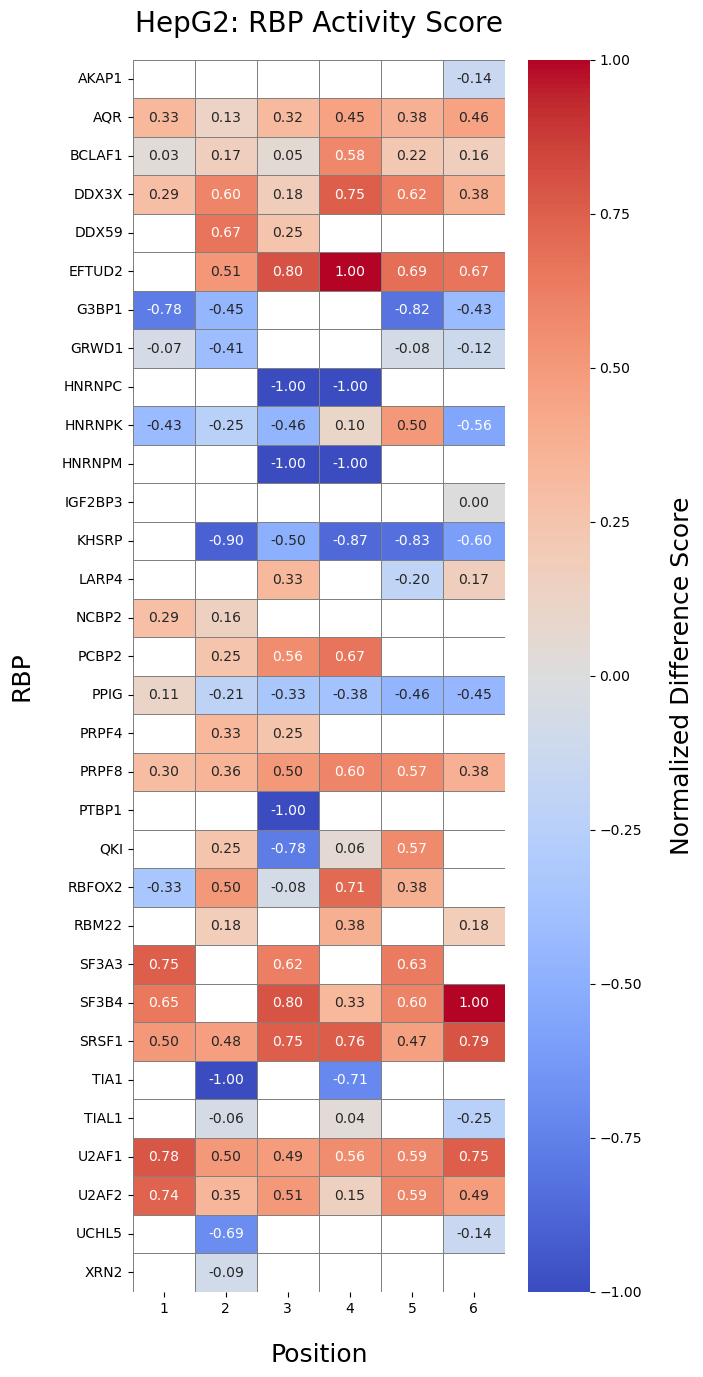

In [38]:
h = plot_rbp_activity_heatmap('HepG2')

## K562

K562


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


['AARS', 'AATF', 'ABCF1', 'AGGF1', 'AKAP1', 'AKAP8L', 'APOBEC3C', 'AQR', 'BUD13', 'CPEB4', 'CPSF6', 'CSTF2T', 'DDX1', 'DDX24', 'DDX3X', 'DDX47', 'DDX51', 'DDX52', 'DDX55', 'DHX30', 'DROSHA', 'EEF2', 'EFTUD2', 'EIF3G', 'EIF4G2', 'EWSR1', 'FAM120A', 'FASTKD2', 'FMR1', 'FTO', 'FUS', 'FXR1', 'GEMIN5', 'GPKOW', 'GRWD1', 'GTF2F1', 'HLTF', 'HNRNPA1', 'HNRNPC', 'HNRNPK', 'HNRNPL', 'HNRNPM', 'HNRNPU', 'HNRNPUL1', 'IGF2BP2', 'ILF3', 'KHDRBS1', 'KHSRP', 'LARP4', 'LARP7', 'LIN28B', 'LSM11', 'MATR3', 'MBNL1', 'METAP2', 'MTPAP', 'NCBP2', 'NONO', 'NSUN2', 'PABPC4', 'PCBP1', 'PHF6', 'PPIL4', 'PTBP1', 'PUM1', 'PUM2', 'PUS1', 'QKI', 'RBFOX2', 'RBM15', 'RBM22', 'RPS10', 'SAFB2', 'SBDS', 'SERBP1', 'SF3B4', 'SLBP', 'SLTM', 'SMNDC1', 'SND1', 'SRSF1', 'SSB', 'SUPV3L1', 'TAF15', 'TARDBP', 'TBRG4', 'TIA1', 'TROVE2', 'U2AF1', 'U2AF2', 'UCHL5', 'UPF1', 'UTP18', 'UTP3', 'WDR3', 'WDR43', 'WRN', 'XRN2', 'YBX3', 'ZC3H8', 'ZRANB2']
       RBP  position  num_pos  num_neg  norm_diff
53  RBFOX2         3        4       

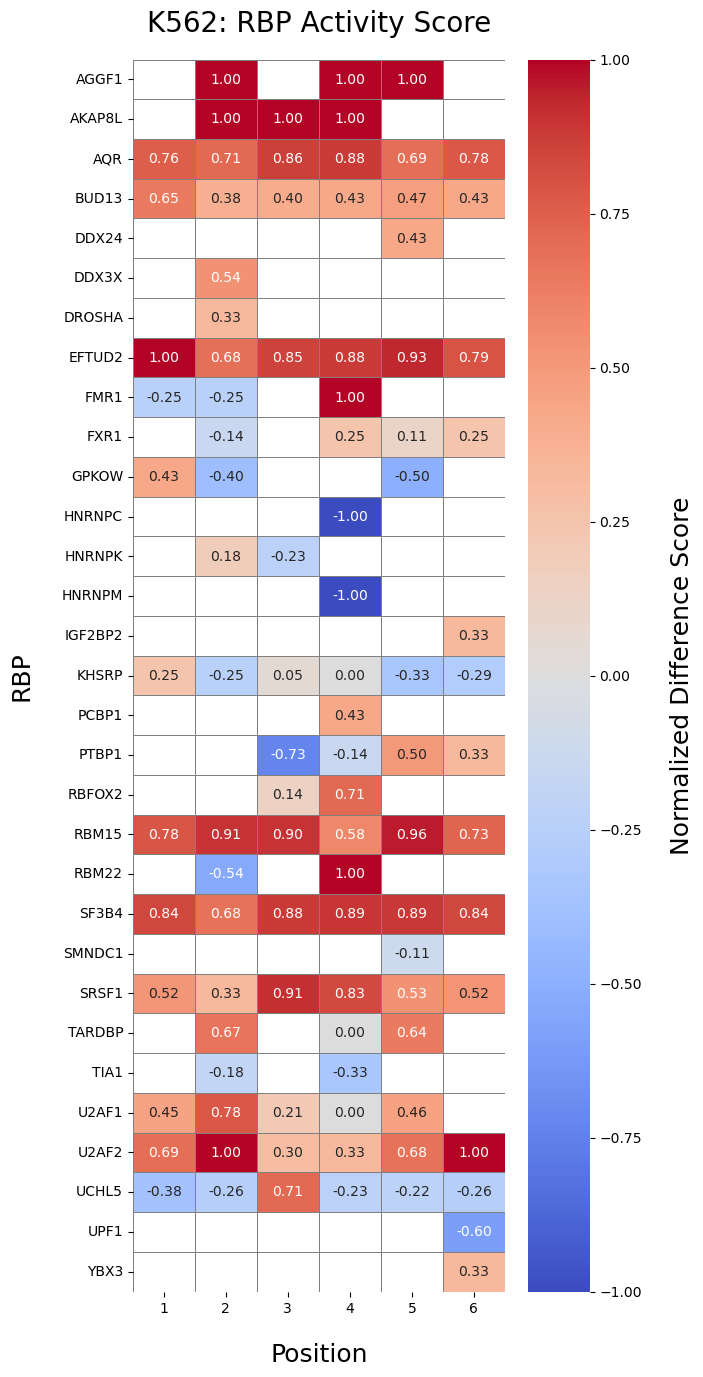

In [28]:
k = plot_rbp_activity_heatmap('K562')

## SHAP vs RBP Activity Score Scatterplot

In [7]:
# Creating the source table

def rbp_activity_table(cell_line):
    
    print(cell_line)
    
    # read in data 
    
    data_path = f"/project/PlatigLab/users/yogi/backups/2025-08-28_probability_SHAP_with_all_training_UBPs_as_background/FINAL_AVERAGE_SHAP_CACHE/{cell_line}_all-data.feather"
    
    data = pl.read_ipc(data_path)
    
    # Filter massive dataframe for KD samples, FDR <= 0.05, abs[DeltaPSI] >= 0.05

    filtered_data = (
        data
        .filter(
            (data["Sample Name"].str.contains("KD", literal=True))
            & (data["FDR"] <= 0.05)
            & (data["DeltaPSI"].abs() >= 0.05)
        )    
    )

    # Columns 
    columns_to_keep = [
        "RBP_KD_Target",
        "Sample Name",
        "FDR",
        "DeltaPSI",
        "has_RBP_KD_1",
        "has_RBP_KD_2",
        "has_RBP_KD_3",
        "has_RBP_KD_4",
        "has_RBP_KD_5",
        "has_RBP_KD_6",
        "Raw P-Val",
        "rMATS Event ID"
    ]
    
    rbp_targets = (
        filtered_data["RBP_KD_Target"]
        .unique()
        .sort()
        .to_list()
    )
    
    positions = [1,2,3,4,5,6]

    results = []  # collect all results here

    for rbp in rbp_targets:
        for pos in positions:

            rbp_specific_data = (
            filtered_data
            .filter(
                (pl.col("RBP_KD_Target") == rbp) & (pl.col(f"has_RBP_KD_{pos}") == True))
            .unique(subset=["rMATS Event ID"])) # gets in-silico KD rows per RBP per position

            # Drop unneccesary columns
            rbp_specific_data = rbp_specific_data.select(columns_to_keep)

            # Convert to pandas
            df = rbp_specific_data.to_pandas()

            # Prevents error for no data (SAFB or IGF..1)
            data = df["DeltaPSI"]

            if data.empty:
                continue 

            # DPSI conversion
            df["DeltaPSI"] = df["DeltaPSI"] * -1

            # Calculate the number of positive dPSI and the number of negative dPSI

            num_pos = (df["DeltaPSI"] > 0).sum()
            num_neg = (df["DeltaPSI"] < 0).sum()

            # Do not include rows plots with less than 6 sig. points 

            if (num_pos + num_neg) < 6:
                continue 

            # Normalized Difference Score
            norm_diff = (num_pos - num_neg) / (num_pos + num_neg)

            # Append results
            results.append({
                "RBP": rbp,
                "Position": pos,
                "num_pos": num_pos,
                "num_neg": num_neg,
                "norm_diff": norm_diff
            })

    # Final results dataframe
    results_df = pd.DataFrame(results)
    
    # Can test for an individual RBP
    # test = results_df[results_df["RBP"] == ""]
    # print(test)
    
    df = pd.DataFrame(results_df)
    
    # Read in glossary heatmap data
    glossary_data_path = f"/project/PlatigLab/users/reece/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/07_reece_biological_validations/1_shap_vs_dpsi_analysis/data/{cell_line}_global_SHAP_Signed-Local-SHAP-Mean-Bound-Only.tsv"

    glossary_data = pd.read_csv(glossary_data_path, sep='\t')
    
    # Melt glossary from wide to long so it matches activity data structure

    glossary_long = glossary_data.melt(id_vars="Position", var_name="RBP", value_name="shap")

    # Merge on position + RBP
    merged = df.merge(glossary_long, on=["RBP", "Position"], how="left")
    
    # Scatterplot

    conditions = [
        (merged["shap"] > 0) & (merged["norm_diff"] > 0),   # Q1
        (merged["shap"] < 0) & (merged["norm_diff"] > 0),   # Q2
        (merged["shap"] < 0) & (merged["norm_diff"] < 0),   # Q3
        (merged["shap"] > 0) & (merged["norm_diff"] < 0),   # Q4
    ]

    colors = ["red", "gray", "blue", "gray"]

    merged["quadrant_color"] = np.select(conditions, colors, default="black")


    plt.figure(figsize=(8, 6))
    plt.scatter(merged["shap"], merged["norm_diff"], c=merged["quadrant_color"], alpha=0.7)

    # Add horizontal & vertical lines at 0 to create 4 quadrants
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)

    # Labels & title
    plt.xlabel("Mean Local SHAP", fontsize = 19, labelpad = 15)
    plt.ylabel("RBP Activity Score", fontsize = 19, labelpad = 15)
    plt.title(f"{cell_line}: RBP Activity Score vs Mean Local SHAP", fontsize = 19, pad = 15)

    plt.show()

    return 

HepG2


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


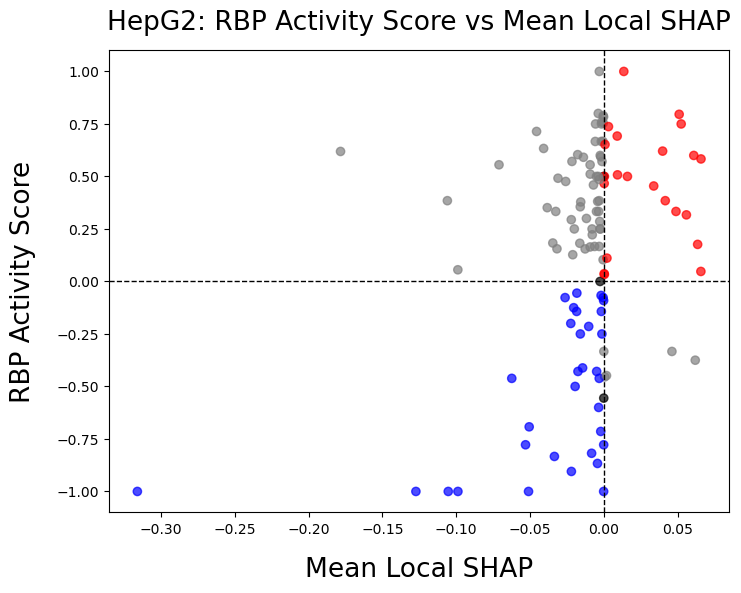

In [8]:
hepg2_data = rbp_activity_table('HepG2')

K562


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


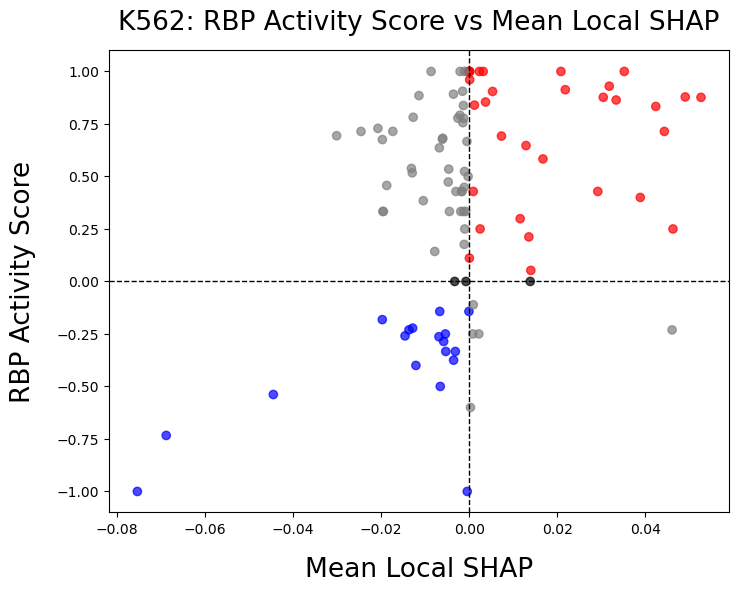

In [9]:
k562_data = rbp_activity_table('K562')